# 03 · Problema 1: ¿cuánto se comerciará el próximo mes? (regresión)

**Fase CRISP-DM:** modelado (§1–5) y evaluación técnica (§6–8) para la pregunta 3 del proyecto.
La sección 9 contrasta el resultado con esa pregunta.

## Definición del problema

| Elemento | Decisión | Justificación |
|---|---|---|
| **Unidad** | Serie = (flujo, producto HS6, país) | Dimensiones estables en el tiempo (los IDs de empresa no lo son) |
| **Población** | Series **regulares**: comercio en ≥ 10 de los últimos 12 meses, evaluado **en cada origen** con datos pasados | Concentran ~87–90% del valor; elegirlas mirando el futuro sería *leakage* de selección |
| **Objetivo** | Valor (US$) del mes t + h, h ∈ {1, 2, 3} | "Los meses siguientes"; un modelo por horizonte (estrategia *directa*) |
| **Validación** | *Walk-forward* con reentrenamiento mensual | Imita producción: en cada mes solo se conoce el pasado |
| **Períodos** | Validación: objetivos jul–dic 2025 · **Test: ene–ago 2026** (una sola evaluación) | El test incluye el shock de precios de 2026 |
| **Métricas** | WAPE (US$), MAE en log (por serie), sesgo del total | Negocio (dólares), calidad típica por serie y error del agregado |

**Notebook = experimentación + resultado final.** Las secciones 3–5 muestran el camino (incluidos los
intentos que fallaron y por qué); la sección 6 es el resultado final con la configuración congelada.

In [1]:
import subprocess, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from comercio_chile import viz, forecast as F
from comercio_chile.features import load_grid, regular_mask, features, target
from comercio_chile.config import PROCESSED, ROOT

viz.setup()
warnings.filterwarnings("ignore", message=".*eval_set.*")
pd.set_option("display.width", 220)
FLOWS = ["exportaciones", "importaciones"]
G = {f: load_grid(f) for f in FLOWS}
VAL = [str(p) for p in pd.period_range("2025-07", "2025-12", freq="M")]
TEST = [str(p) for p in pd.period_range("2026-01", "2026-08", freq="M")]
BASE = F.ModelConfig().params
L1 = F.ModelConfig(params={**BASE, "objective": "l1"}, target="delta")
TWEEDIE = F.ModelConfig(params={**BASE, "objective": "tweedie", "tweedie_variance_power": 1.5}, target="raw_offset")
BASELINES = list(F.BASELINES)

rows = []
for f, g in G.items():
    for per in ["2024-12", "2025-06", "2025-12", "2026-07"]:
        t = g.t_of(per); m = regular_mask(g, t)
        rows.append({"flujo": f, "origen": per, "series regulares": int(m.sum()),
                     "% valor del mes siguiente cubierto": 100 * g.valor[m, t + 1].sum() / g.valor[:, t + 1].sum()})
pd.DataFrame(rows).set_index(["flujo", "origen"]).round(1)

series regulares  % valor del mes siguiente cubierto
flujo         origen                                                       
exportaciones 2024-12              2798                                70.6
              2025-06              2853                                89.3
              2025-12              2861                                86.9
              2026-07              3003                                89.1
importaciones 2024-12             13492                                87.2
              2025-06             13722                                89.1
              2025-12             13761                                87.9
              2026-07             13652                                90.1

## 1. Prevención de *data leakage*, verificada con tests

El *leakage* temporal es el error más común y caro en forecasting: el modelo "ve" el futuro en
entrenamiento y luego falla en producción. Tres reglas:
1. **Features:** en el origen t solo se leen meses ≤ t (incluido el ranking de países, ver abajo).
2. **Entrenamiento:** en el origen t₀ solo se usan pares cuyo objetivo ya se observó (t + h ≤ t₀). Con
   h = 3, los objetivos de los 2 últimos meses todavía no existen.
3. **Selección de series:** la regularidad se evalúa con los 12 meses previos a cada origen.

No basta con afirmarlo: `tests/test_no_leakage.py` **altera con ruido todos los datos posteriores a t₀** y
verifica que las features y el set de entrenamiento queden idénticos.

> **El test encontró un leakage real** durante el desarrollo: la categoría `pais` agrupaba como "otro" a
> los países fuera del top-40 calculado con **todo el período**, incluidos los meses futuros. Se corrigió
> calculando el ranking solo con meses ≤ t, y todos los resultados de este notebook usan la versión corregida.

In [2]:
r = subprocess.run([sys.executable, "-m", "pytest", str(ROOT / "tests"), "-q", "--color=no", "-p", "no:cacheprovider"],
                   capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])

15 passed, 6 warnings in 7.28s


## 2. Baselines

| Baseline | Predicción para t + h | Captura |
|---|---|---|
| **Naive** | valor en t | Persistencia |
| **Naive estacional** | valor en t + h − 12 | Estacionalidad |
| **Estacional con tendencia** | valor en t + h − 12 × (Σ últimos 3 meses / Σ mismos 3 meses del año anterior) | Estacionalidad + crecimiento |
| **Media móvil 3** | promedio de t−2..t | Nivel reciente, sin ruido mensual |

Un modelo de machine learning **solo se justifica si supera a estos baselines**. En forecasting, muchos
modelos complejos no lo logran.

## 3. Experimentación: cuatro intentos y lo que enseñó cada uno (validación, h = 1)

In [3]:
VARIANTES = {
    "A · L2 sobre log(1+y)": F.ModelConfig(target="log1p"),
    "B · L1 sobre log(1+y)": F.ModelConfig(params={**BASE, "objective": "l1"}, target="log1p"),
    "C · L1 sobre cambio relativo": L1,
    "D · Huber sobre cambio relativo": F.ModelConfig(params={**BASE, "objective": "huber", "alpha": 1.0}, target="delta"),
    "E · Tweedie en US$ con offset": TWEEDIE,
}
res = []
for f, g in G.items():
    for name, cfg in VARIANTES.items():
        p = F.walk_forward(g, 1, VAL, cfg)
        res.append({"flujo": f, "variante": name, **F.metrics(p.y.to_numpy(), p.modelo.to_numpy())})
    for b in ["media_movil_3", "naive"]:
        res.append({"flujo": f, "variante": f"baseline · {b}", **F.metrics(p.y.to_numpy(), p[b].to_numpy())})
exp = pd.DataFrame(res).set_index(["flujo", "variante"]).drop(columns="n")
exp.round(3)

WAPE  MAE_log  sesgo_total
flujo         variante                                                    
exportaciones A · L2 sobre log(1+y)            0.590    1.877       -0.467
              B · L1 sobre log(1+y)            0.556    1.622       -0.400
              C · L1 sobre cambio relativo     0.311    1.616       -0.070
              D · Huber sobre cambio relativo  0.308    1.619       -0.105
              E · Tweedie en US$ con offset    0.310    1.669       -0.034
              baseline · media_movil_3         0.316    1.681       -0.028
              baseline · naive                 0.362    1.983       -0.032
importaciones A · L2 sobre log(1+y)            0.554    1.555       -0.392
              B · L1 sobre log(1+y)            0.505    1.405       -0.245
              C · L1 sobre cambio relativo     0.419    1.403       -0.136
              D · Huber sobre cambio relativo  0.423    1.404       -0.164
              E · Tweedie en US$ con offset    0.432    1.485       -0.040
              baseline · media_movil_3         0.442    1.494       -0.005
              baseline · naive                 0.510    1.831       -0.008

**Lo que enseñó cada intento:**

**A → B: la función de pérdida debe calzar con la métrica.** L2 estima la **media del logaritmo**. Las
series regulares a veces tienen meses en 0, y en escala log eso es un error enorme que L2 (al elevarlo al
cuadrado) usa para arrastrar todas las predicciones hacia abajo. Además, `exp(media del log)` es la media
**geométrica**, menor que la aritmética (Jensen). L1 estima la **mediana**, y como la mediana conmuta con
transformaciones monótonas (mediana de log y = log de la mediana de y), `exp` devuelve la mediana en dólares
**sin sesgo de retransformación**. La mediana es, además, el pronóstico óptimo para un error absoluto como
el WAPE. Resultado: el MAE log mejora fuerte, pero el WAPE sigue mal.

**B → C: el problema era la escala.** Un modelo global de árboles con objetivo en nivel absoluto pone en la
misma hoja (mínimo 50 observaciones) a las pocas series gigantes de cobre junto con series menores, y
"encoge" sus predicciones. Como el WAPE lo dominan esas series, el error en dólares se dispara. Solución
estándar en forecasting global (escalamiento por serie, como en DeepAR): modelar el **cambio relativo al
nivel reciente**, log(1+y_{t+h}) − log(1 + media de 3 meses). El objetivo queda sin escala, y +10% significa
lo mismo para el cobre que para un producto pequeño.

**C vs E: mediana vs media, un trade-off sin ganador.** L1 (mediana) da el mejor error **por serie**, pero
la suma de medianas subestima el **total**, porque la distribución tiene cola a la derecha. Tweedie con
offset `log(nivel)` modela la **media** con un link logarítmico y es la elección para el total agregado.
Se conservan **ambos modelos**, cada uno para su uso.

## 4. Sensibilidad y principio de parsimonia

In [4]:
L1P = {**BASE, "objective": "l1"}
SENS = {"L1 · sin ponderar (elegido)": L1,
        "L1 · peso log(valor)": F.ModelConfig(params=L1P, target="delta", weighting="log"),
        "L1 · peso √valor": F.ModelConfig(params=L1P, target="delta", weighting="sqrt"),
        "L1 · árbol simple (15 hojas, mín. 100)": F.ModelConfig(params={**L1P, "num_leaves": 15, "min_child_samples": 100}, target="delta"),
        "L1 · árbol complejo (63 hojas, mín. 20)": F.ModelConfig(params={**L1P, "num_leaves": 63, "min_child_samples": 20}, target="delta")}
res = []
for f, g in G.items():
    for name, cfg in SENS.items():
        p = F.walk_forward(g, 1, VAL, cfg)
        res.append({"flujo": f, "variante": name, **F.metrics(p.y.to_numpy(), p.modelo.to_numpy())})
pd.DataFrame(res).set_index(["flujo", "variante"]).drop(columns="n").round(3)

WAPE  MAE_log  sesgo_total
flujo         variante                                                            
exportaciones L1 · sin ponderar (elegido)              0.311    1.616       -0.070
              L1 · peso log(valor)                     0.319    1.614       -0.051
              L1 · peso √valor                         0.307    1.621       -0.078
              L1 · árbol simple (15 hojas, mín. 100)   0.316    1.615       -0.062
              L1 · árbol complejo (63 hojas, mín. 20)  0.307    1.620       -0.058
importaciones L1 · sin ponderar (elegido)              0.419    1.403       -0.136
              L1 · peso log(valor)                     0.418    1.403       -0.134
              L1 · peso √valor                         0.418    1.407       -0.132
              L1 · árbol simple (15 hojas, mín. 100)   0.420    1.403       -0.138
              L1 · árbol complejo (63 hojas, mín. 20)  0.416    1.403       -0.135

**Lectura:** todas las variantes quedan dentro de ~±0,01 de WAPE y no hay una mejora consistente en ambos
flujos. **Elegir la "mejor" de esta tabla sería sobreajustar al período de validación**: con 6 meses, una
diferencia de 0,005 es ruido. Se aplica **parsimonia**: la configuración más simple (sin ponderar, complejidad
por defecto). Que el modelo sea poco sensible a estos hiperparámetros también es una buena noticia: el
resultado no depende de un ajuste fino frágil.

## 5. ¿Sobreajuste o subajuste?

**Sobreajuste** = el modelo memoriza el entrenamiento y generaliza mal (error de entrenamiento muy bajo, de
validación alto). **Subajuste** = es demasiado simple incluso para el entrenamiento. Dos diagnósticos:
1. **Curva de aprendizaje:** error de entrenamiento y validación según el n.º de árboles (*boosting rounds*).
2. **Curva de complejidad:** error según el tamaño de los árboles (n.º de hojas).

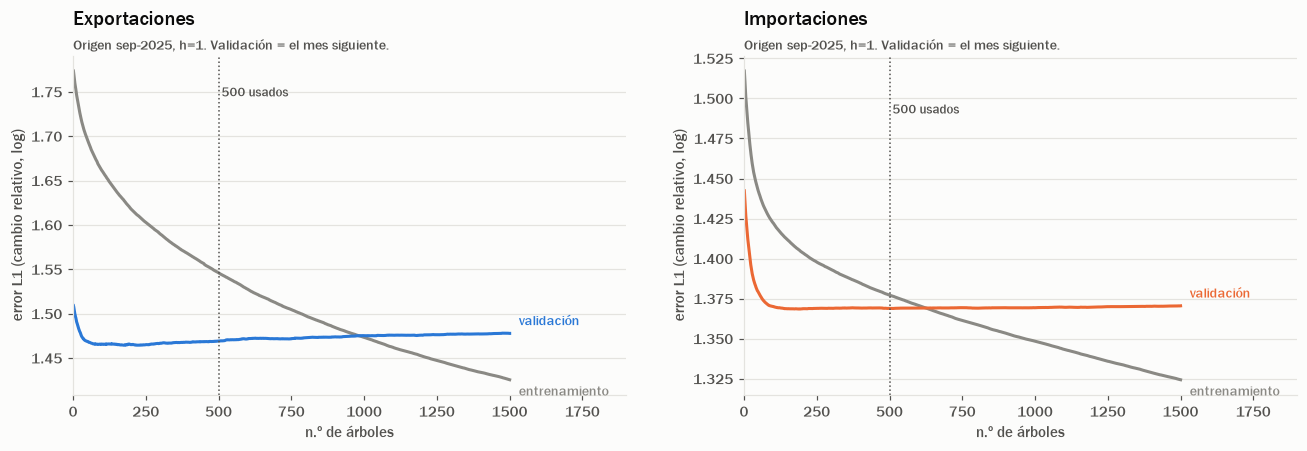

,exportaciones,importaciones
L1 entren. @500,1.5461,1.3772
L1 valid. @500,1.4692,1.3689
mejor valid.,1.4644,1.3685
iteración del mínimo,173.0000,187.0000
L1 valid. @1500,1.4778,1.3705


In [5]:
def train_valid(g, t0, h=1):
    X, y = F.training_set(g, t0, h)
    rows = np.where(regular_mask(g, t0))[0]
    Xv = features(g, t0, h, rows); yv = target(g, t0, h, rows)
    for c in ("capitulo", "pais"):
        Xv[c] = pd.Categorical(Xv[c].astype(str), categories=X[c].cat.categories)
    enc = lambda X_, y_: np.log1p(y_) - X_["log_media_3"].to_numpy()
    return X, enc(X, y), Xv, enc(Xv, yv)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
curvas = {}
for ax, f, color in zip(axes, FLOWS, [viz.EXPORT, viz.IMPORT]):
    g = G[f]; X, y, Xv, yv = train_valid(g, g.t_of("2025-09"))
    ev = {}
    m = lgb.LGBMRegressor(**{**L1.params, "n_estimators": 1500}).fit(
        X, y, eval_set=[(X, y), (Xv, yv)], eval_names=["entrenamiento", "validación"], eval_metric="l1",
        callbacks=[lgb.record_evaluation(ev)])
    tr, va = np.array(ev["entrenamiento"]["l1"]), np.array(ev["validación"]["l1"])
    curvas[f] = (tr, va)
    it = np.arange(1, len(tr) + 1)
    ax.plot(it, tr, color=viz.NEUTRAL); ax.plot(it, va, color=color)
    viz.label_end(ax, it[-1], tr[-1], "entrenamiento", viz.NEUTRAL, dy=-8)
    viz.label_end(ax, it[-1], va[-1], "validación", color, dy=8)
    ax.axvline(500, color=viz.TEXT_2, ls=":", lw=1); ax.text(510, ax.get_ylim()[1] * 0.98, "500 usados", fontsize=8.5, color=viz.TEXT_2, va="top")
    ax.set_xlim(0, 1900); ax.set_xlabel("n.º de árboles"); ax.set_ylabel("error L1 (cambio relativo, log)")
    ax.set_title(f.capitalize())
    viz.subtitle(ax, "Origen sep-2025, h=1. Validación = el mes siguiente.")
fig.tight_layout(w_pad=3)
viz.save(fig, "13_curva_aprendizaje"); display(fig); plt.close(fig)
pd.DataFrame({f: {"L1 entren. @500": tr[499], "L1 valid. @500": va[499], "mejor valid.": va.min(),
                  "iteración del mínimo": int(va.argmin()) + 1, "L1 valid. @1500": va[-1]}
              for f, (tr, va) in curvas.items()}).round(4)

In [6]:
rows = []
for f in FLOWS:
    g = G[f]; X, y, Xv, yv = train_valid(g, g.t_of("2025-09"))
    for nl in [2, 4, 8, 15, 31, 63, 127, 255]:
        m = lgb.LGBMRegressor(**{**L1.params, "num_leaves": nl, "min_child_samples": 20}).fit(X, y)
        rows.append({"flujo": f, "hojas": nl, "error entrenamiento": np.abs(m.predict(X) - y).mean(),
                     "error validación": np.abs(m.predict(Xv) - yv).mean()})
cc = pd.DataFrame(rows)
cc["brecha"] = cc["error validación"] - cc["error entrenamiento"]
cc.pivot_table(index="hojas", columns="flujo", values=["error entrenamiento", "error validación", "brecha"]).round(4)

brecha               error entrenamiento               error validación              
flujo exportaciones importaciones       exportaciones importaciones    exportaciones importaciones
hojas                                                                                             
2           -0.2392       -0.0653              1.7131        1.4416           1.4739        1.3763
4           -0.2116       -0.0550              1.6814        1.4282           1.4697        1.3732
8           -0.1791       -0.0436              1.6468        1.4149           1.4678        1.3713
15          -0.1352       -0.0304              1.6061        1.4000           1.4709        1.3697
31          -0.0621       -0.0063              1.5333        1.3758           1.4712        1.3696
63           0.0431        0.0305              1.4321        1.3382           1.4752        1.3687
127          0.2015        0.0944              1.2884        1.2760           1.4899        1.3704
255          0.3804        0.1832              1.1376        1.1905           1.5180        1.3738

**Lectura:**
- **Curva de aprendizaje:** el error de entrenamiento baja sin parar (el modelo sigue memorizando), pero el
  de validación alcanza su **mínimo cerca de los 180 árboles** y luego **sube levemente** (+0,3% a los 500
  usados; +0,9% a los 1.500). Es **sobreajuste leve**: pasado cierto punto, los árboles nuevos aprenden ruido
  del entrenamiento. El efecto de usar 500 es pequeño, y elegir 180 mirando **un solo origen** sería otra
  forma de sobreajuste. Queda documentado como ajuste posible (*early stopping* con un mes de validación
  interno en cada origen).
- **Curva de complejidad:** con 2 hojas el error de entrenamiento es alto (**subajuste**: el modelo es
  demasiado simple). El error de validación es prácticamente **plano entre 4 y 63 hojas** y **sube desde
  127**, mientras la brecha entrenamiento–validación crece de forma monótona: **sobreajuste claro con
  árboles grandes**. 31 hojas está en la zona plana.
- **¿Por qué el error de entrenamiento supera al de validación con modelos simples?** Las dos cifras no son
  directamente comparables. El entrenamiento mezcla ~10 meses de orígenes (algunos más volátiles) y la
  validación es un solo mes. Lo que importa son las **tendencias** de cada curva y cómo evoluciona la brecha.

## 6. Resultado final: test ene–ago 2026 (configuración congelada, evaluación única)

In [7]:
allp = []
for f, g in G.items():
    for h in [1, 2, 3]:
        for per, targets in [("validación", VAL), ("test", TEST)]:
            p = F.walk_forward(g, h, targets, L1).rename(columns={"modelo": "L1"})
            p["Tweedie"] = F.walk_forward(g, h, targets, TWEEDIE).modelo.to_numpy()
            p["flujo"], p["periodo_eval"] = f, per
            allp.append(p)
P = pd.concat(allp, ignore_index=True)
P.to_parquet(PROCESSED / "forecast_predicciones.parquet")
METODOS = ["L1", "Tweedie", "media_movil_3", "naive", "naive_estacional", "estacional_tendencia"]
S = F.score(P, METODOS, by=["flujo", "periodo_eval", "h"])
S.pivot_table(index=["flujo", "periodo_eval", "h"], columns="metodo", values="WAPE")[METODOS].round(3)

metodo                           L1  Tweedie  media_movil_3  naive  naive_estacional  estacional_tendencia
flujo         periodo_eval h                                                                              
exportaciones test         1  0.319    0.319          0.362  0.391             0.437                 0.458
                           2  0.354    0.367          0.401  0.430             0.436                 0.511
                           3  0.362    0.379          0.419  0.449             0.433                 0.613
              validación   1  0.311    0.310          0.316  0.362             0.352                 0.457
                           2  0.316    0.327          0.326  0.368             0.349                 0.555
                           3  0.345    0.369          0.357  0.403             0.349                 0.609
importaciones test         1  0.409    0.426          0.459  0.514             0.559                 0.679
                           2  0.427    0.450          0.482  0.544             0.560                 0.711
                           3  0.443    0.470          0.506  0.561             0.559                 0.736
              validación   1  0.419    0.432          0.442  0.510             0.547                 0.687
                           2  0.422    0.435          0.465  0.516             0.549                 0.714
                           3  0.441    0.468          0.485  0.546             0.549                 0.738

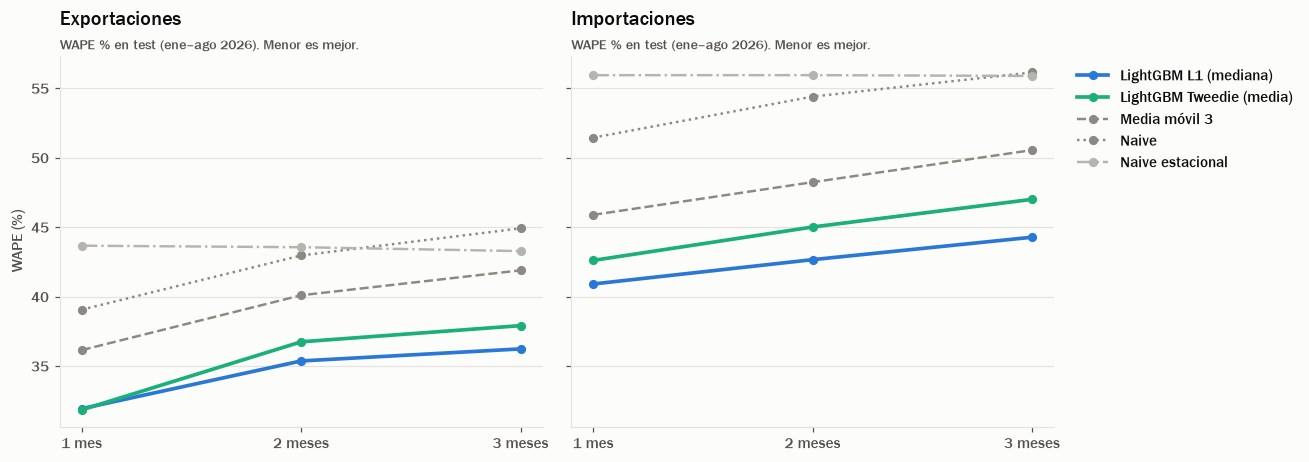

In [8]:
estilo = {"L1": (viz.SERIES[0], "-"), "Tweedie": (viz.SERIES[2], "-"), "media_movil_3": (viz.NEUTRAL, "--"),
          "naive": (viz.NEUTRAL, ":"), "naive_estacional": ("#b5b4ae", "-.")}
nombres = {"L1": "LightGBM L1 (mediana)", "Tweedie": "LightGBM Tweedie (media)", "media_movil_3": "Media móvil 3",
           "naive": "Naive", "naive_estacional": "Naive estacional"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for ax, f in zip(axes, FLOWS):
    st = S[(S.flujo == f) & (S.periodo_eval == "test")]
    for m_, (c, ls) in estilo.items():
        v = st[st.metodo == m_].sort_values("h")
        ax.plot(v.h, 100 * v.WAPE, color=c, ls=ls, marker="o", markersize=5, lw=2.4 if m_ in ("L1", "Tweedie") else 1.6, label=nombres[m_])
    ax.set_xticks([1, 2, 3], ["1 mes", "2 meses", "3 meses"]); ax.set_title(f.capitalize())
    viz.subtitle(ax, "WAPE % en test (ene–ago 2026). Menor es mejor.")
axes[0].set_ylabel("WAPE (%)"); axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))
fig.tight_layout()
viz.save(fig, "14_wape_horizonte"); fig

In [9]:
T1 = P[(P.periodo_eval == "test") & (P.h == 1)]
mensual = F.score(T1, ["L1", "media_movil_3"], by=["flujo", "periodo"]).pivot_table(index=["flujo", "periodo"], columns="metodo", values="WAPE")
mensual["L1 mejor"] = mensual.L1 < mensual.media_movil_3
print("Meses en que L1 supera a la media móvil:", mensual.groupby(level=0)["L1 mejor"].sum().to_dict(), "de 8")

rng = np.random.default_rng(42); ci = {}
for f, g in T1.groupby("flujo"):
    ser = g.serie.unique(); idx = g.groupby("serie").indices
    y = g.y.to_numpy(); a = np.abs(g.L1.to_numpy() - y); b = np.abs(g.media_movil_3.to_numpy() - y)
    d = np.array([(a[s].sum() - b[s].sum()) / y[s].sum() for s in (np.concatenate([idx[k] for k in rng.choice(ser, len(ser))]) for _ in range(300))])
    ci[f] = {"ΔWAPE L1 − media móvil": d.mean(), "IC95% inf": np.quantile(d, .025), "IC95% sup": np.quantile(d, .975)}
display(pd.DataFrame(ci).T.round(4))
seg = F.score(T1, ["L1", "Tweedie", "media_movil_3", "naive"], by=["flujo", "commodity"])
seg["segmento"] = np.where(seg.commodity, "commodities", "resto")
seg.pivot_table(index=["flujo", "segmento"], columns="metodo", values=["WAPE", "sesgo_total"]).round(3)

Meses en que L1 supera a la media móvil: {'exportaciones': 8, 'importaciones': 8} de 8


,ΔWAPE L1 − media móvil,IC95% inf,IC95% sup
exportaciones,-0.0456,-0.1036,-0.0139
importaciones,-0.0502,-0.0624,-0.0384


WAPE                              sesgo_total                             
metodo                        L1 Tweedie media_movil_3  naive          L1 Tweedie media_movil_3  naive
flujo         segmento                                                                                
exportaciones commodities  0.294   0.292         0.300  0.358      -0.092  -0.080        -0.052 -0.020
              resto        0.396   0.398         0.548  0.490      -0.096  -0.027         0.043  0.045
importaciones commodities  0.352   0.367         0.372  0.433      -0.159  -0.116        -0.059 -0.022
              resto        0.427   0.444         0.486  0.540      -0.101   0.007        -0.012  0.003

**Lectura del test:**
- **L1 supera a todos los baselines en todos los horizontes y en ambos flujos**, con WAPE 11–14% menor que el
  mejor baseline (media móvil 3). Gana **en los 8 meses de 2026** en ambos flujos, y el intervalo de
  confianza de la mejora (bootstrap por serie) excluye el cero.
- **El error crece con el horizonte** (h = 3 > h = 1), como es de esperar: más incertidumbre. La ventaja del
  modelo sobre los baselines se mantiene.
- **Dónde agrega valor:** en exportaciones, la ganancia viene sobre todo de los **no-commodities**. En
  commodities, el modelo apenas mejora a la media móvil: su precio es **exógeno** (se fija en Londres o
  Shanghái), y con nuestros datos ningún modelo puede hacer mucho más que seguir el nivel reciente.
- **Validación vs test:** en exportaciones, L1 empataba con la media móvil en validación pero la supera en
  test. En 2026 los precios subieron rápido: la media móvil arrastra 3 meses de precios viejos, mientras el
  modelo usa el momentum del precio y del sector.
- **El naive estacional con tendencia es el peor:** extrapolar el crecimiento amplifica el ruido. El baseline
  más "sofisticado" no es el mejor.

## 7. El total agregado: ¿cuánto se exportará e importará?

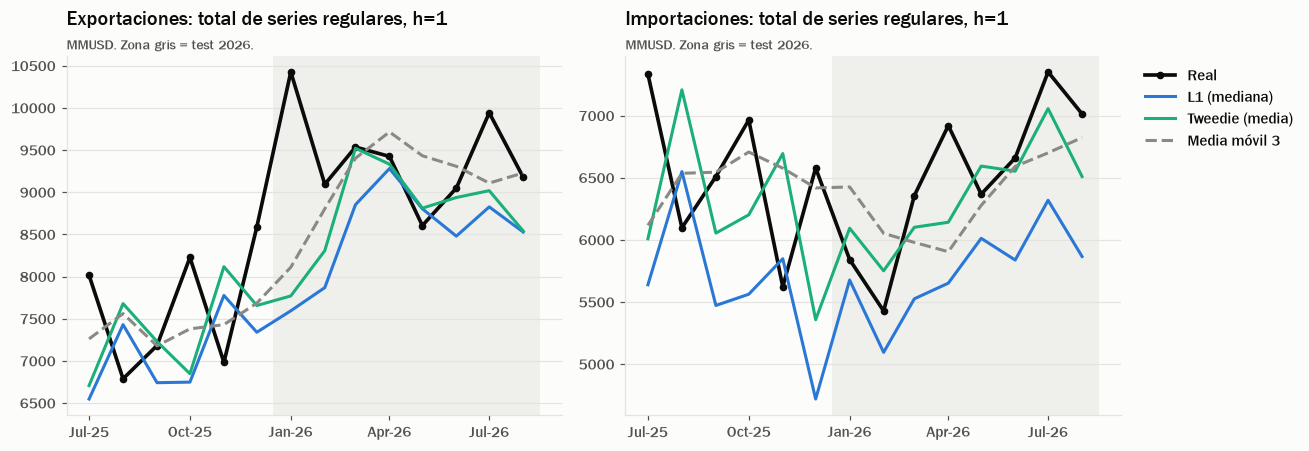

metodo                           L1  Tweedie  media_movil_3
flujo         periodo_eval h                               
exportaciones test         1 -0.093   -0.067         -0.028
                           2 -0.117   -0.059         -0.045
                           3 -0.131   -0.103         -0.060
              validación   1 -0.070   -0.034         -0.028
                           2 -0.069   -0.040         -0.026
                           3 -0.064   -0.049         -0.030
importaciones test         1 -0.115   -0.022         -0.023
                           2 -0.095   -0.004         -0.030
                           3 -0.101    0.017         -0.030
              validación   1 -0.136   -0.040         -0.005
                           2 -0.114   -0.018         -0.010
                           3 -0.113   -0.024         -0.024

In [10]:
tot = P[P.h == 1].groupby(["flujo", "periodo"])[["y", "L1", "Tweedie", "media_movil_3"]].sum() / 1e6
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, f in zip(axes, FLOWS):
    d = tot.loc[f]; x = pd.PeriodIndex(d.index, freq="M").to_timestamp()
    ax.plot(x, d.y, color=viz.TEXT, lw=2.4, marker="o", markersize=4, label="Real")
    ax.plot(x, d.L1, color=viz.SERIES[0], label="L1 (mediana)")
    ax.plot(x, d.Tweedie, color=viz.SERIES[2], label="Tweedie (media)")
    ax.plot(x, d.media_movil_3, color=viz.NEUTRAL, ls="--", label="Media móvil 3")
    ax.axvspan(pd.Timestamp("2025-12-16"), x[-1] + pd.Timedelta(days=15), color=viz.GRID, alpha=0.5, lw=0)
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b-%y"))
    ax.set_title(f"{f.capitalize()}: total de series regulares, h=1")
    viz.subtitle(ax, "MMUSD. Zona gris = test 2026.")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))
fig.tight_layout()
viz.save(fig, "15_total_pronosticado"); display(fig); plt.close(fig)
S[S.metodo.isin(["L1", "Tweedie", "media_movil_3"])].pivot_table(index=["flujo", "periodo_eval", "h"], columns="metodo", values="sesgo_total").round(3)

**Lectura:**
- **L1 subestima sistemáticamente el total**, como predice la teoría: la suma de medianas es menor que la
  suma de medias. En exportaciones 2026 el sesgo se agrava (precios al alza que el historial no anticipaba).
- **Tweedie reduce el sesgo del total**, al costo de un error por serie algo mayor. Para un reporte agregado
  ("¿cuánto exportará Chile en marzo?"), el modelo Tweedie es el adecuado.
- **La media móvil tiene un sesgo de total bajo** porque es "insesgada" en promedio, aunque su error por
  serie es mucho peor. **Ningún método gana en todo:** la elección depende de la pregunta de negocio.
- La subestimación persistente de 2026 en exportaciones es una **señal de drift** (el concepto cambió: mismo
  volumen, precio mayor). Se monitorea formalmente en la etapa siguiente.

## 8. ¿Qué aprendió el modelo? (interpretabilidad con SHAP)

Los valores **SHAP** descomponen cada predicción en la contribución de cada feature (teoría de juegos:
valores de Shapley). LightGBM los calcula de forma exacta para árboles (`pred_contrib=True`). El promedio
de |SHAP| mide la importancia global de cada variable.

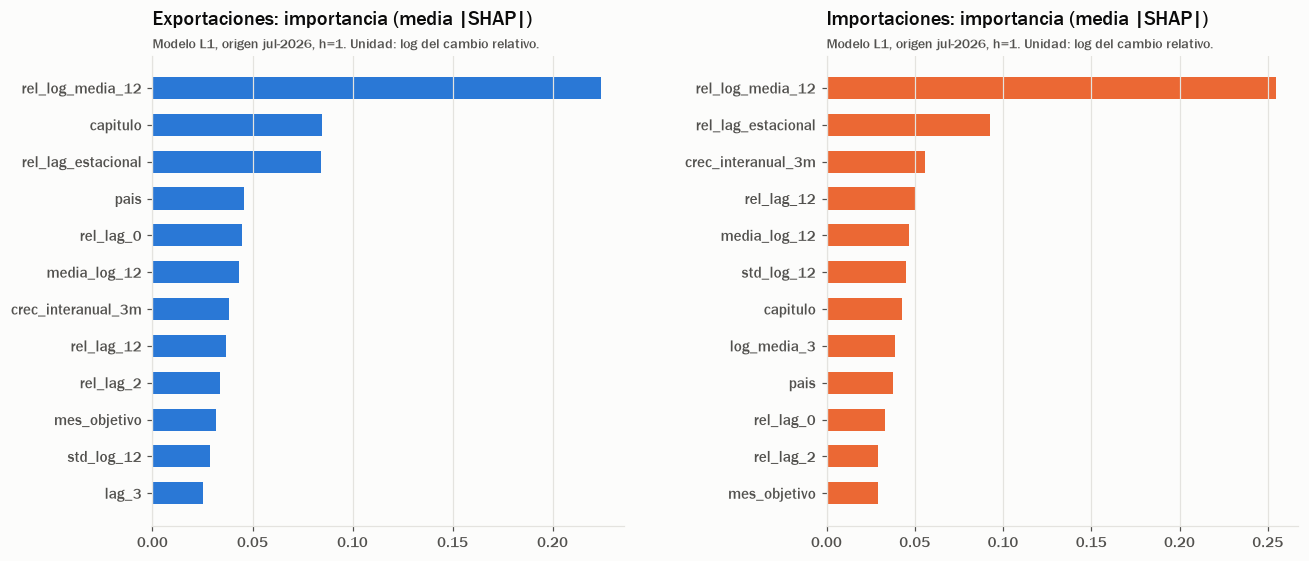

,exportaciones,importaciones
0,rel_log_media_12,rel_log_media_12
1,capitulo,rel_lag_estacional
2,rel_lag_estacional,crec_interanual_3m
3,pais,rel_lag_12
4,rel_lag_0,media_log_12
5,media_log_12,std_log_12
6,crec_interanual_3m,capitulo
7,rel_lag_12,log_media_3
8,rel_lag_2,pais
9,mes_objetivo,rel_lag_0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
imp = {}
for ax, f, color in zip(axes, FLOWS, [viz.EXPORT, viz.IMPORT]):
    g = G[f]; t0 = g.t_of("2026-07")
    model = F.fit(g, t0, 1, L1)
    rows = np.where(regular_mask(g, t0))[0]
    X = features(g, t0, 1, rows)
    for c, cats in model.categories_.items():
        X[c] = pd.Categorical(X[c].astype(str), categories=cats)
    contrib = model.predict(X, pred_contrib=True)[:, :-1]
    s = pd.Series(np.abs(contrib).mean(axis=0), index=X.columns).sort_values(ascending=False)
    imp[f] = s
    top = s.head(12)[::-1]
    ax.barh(top.index, top.values, color=color, height=0.6)
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
    ax.set_title(f"{f.capitalize()}: importancia (media |SHAP|)")
    viz.subtitle(ax, "Modelo L1, origen jul-2026, h=1. Unidad: log del cambio relativo.")
fig.tight_layout(w_pad=4)
viz.save(fig, "16_shap_importancia"); display(fig); plt.close(fig)
pd.DataFrame({f: s.head(10).index for f, s in imp.items()})

**Lectura** (los nombres `rel_*` son features relativas al nivel de los últimos 3 meses):
- La feature más importante, por lejos, es **`rel_log_media_12`**: el nivel de 12 meses frente al de los
  últimos 3. El modelo aprendió **reversión a la media**: si una serie viene por sobre su nivel anual,
  tiende a bajar, y viceversa. Es una regularidad que ningún baseline individual explota.
- Le sigue la **estacionalidad relativa** (`rel_lag_estacional`: el mismo mes del año anterior frente al
  nivel actual), coherente con el EDA (fruta, vino, salmón).
- **Capítulo y país** importan, sobre todo en exportaciones: el modelo global aprende dinámicas propias de
  cada sector y mercado, compartidas entre series.
- El **crecimiento interanual** y la **volatilidad** completan el cuadro. El precio (`precio_vs_mediana12`)
  no aparece en el top: el shock de 2026 lo captura sobre todo vía el nivel y el crecimiento recientes.

## 9. Conclusiones del Problema 1

1. **Un modelo global de LightGBM supera a todos los baselines** en test (WAPE −11 a −13% vs la media móvil
   en los 3 horizontes y ambos flujos; mejor en los 8 meses; IC de la mejora excluye 0).
2. **Las decisiones que más importaron no fueron de hiperparámetros**, sino de **formulación**: la función de
   pérdida (L1 vs L2, mediana vs media) y la **escala del objetivo** (cambio relativo). Pasar de la
   formulación ingenua a la correcta bajó el WAPE de ~0,59 a ~0,31.
3. **Trade-off mediana vs media:** L1 para pronósticos por serie, Tweedie para totales. Ninguno domina.
4. **Limitación de fondo:** en commodities el modelo apenas supera a la media móvil, porque su precio es
   exógeno. Incorporar precios internacionales (cobre LME, litio) como variables sería la mejora de mayor
   impacto.